# Push-Up Posture Checker Dev

This notebook is used for development of the posture-checking pipeline
(rule-based + ML prototype).

The final comparison across MediaPipe/MMPose and 2D/3D, as well as the
final exported MLP models, are handled in notebook 04.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

FRAME_FEATURES_CSV_PATH = PROCESSED_DIR / "pushup_features.csv"
VIDEO_FEATURES_CSV_PATH = PROCESSED_DIR / "pushup_video_level_features.csv"

frame_df = pd.read_csv(FRAME_FEATURES_CSV_PATH)
video_df = pd.read_csv(VIDEO_FEATURES_CSV_PATH)

print("Frame-level shape:", frame_df.shape)
print("Video-level shape:", video_df.shape)

frame_df.head()

Frame-level shape: (10928, 173)
Video-level shape: (100, 42)


,video_name,video_stem,label,frame_index,fps,timestamp_sec,nose_x,nose_y,nose_z,nose_visibility,...,body_alignment_angle_2d_smooth,body_alignment_angle_3d_smooth,hip_angle_2d_smooth,hip_angle_3d_smooth,knee_angle_2d_smooth,knee_angle_3d_smooth,elbow_angle_3d_smooth_diff,body_alignment_angle_3d_smooth_diff,hip_angle_3d_smooth_diff,rep_phase
0,1.mp4,1,incorrect,0,29.97,0.000000,0.639666,0.368928,-0.058671,0.999208,...,176.481196,170.344146,166.108025,153.346879,156.900532,143.099334,NaN,NaN,NaN,top
1,1.mp4,1,incorrect,1,29.97,0.033367,0.639678,0.368796,-0.055482,0.999269,...,177.336497,169.818622,167.188835,155.121383,155.920440,145.340742,0.488152,-0.525524,1.774504,top
2,1.mp4,1,incorrect,2,29.97,0.066733,0.639597,0.368087,-0.048250,0.999331,...,178.023783,169.320917,168.116391,156.588858,155.117997,147.245973,0.448837,-0.497704,1.467476,top
3,1.mp4,1,incorrect,3,29.97,0.100100,0.639678,0.367229,-0.046277,0.999389,...,178.543055,168.851033,168.890693,157.749305,154.493203,148.815027,0.409522,-0.469884,1.160447,top
4,1.mp4,1,incorrect,4,29.97,0.133467,0.639661,0.365993,-0.047264,0.999439,...,178.894313,168.408969,169.511741,158.602723,154.046059,150.047903,0.370207,-0.442064,0.853418,top


In [3]:
print("Frame columns:", len(frame_df.columns))
print("Video columns:", len(video_df.columns))
print(video_df.columns.tolist())

Frame columns: 173
Video columns: 42
['video_name', 'label_first', 'selected_side_<lambda>', 'elbow_angle_2d_smooth_mean', 'elbow_angle_2d_smooth_std', 'elbow_angle_2d_smooth_min', 'elbow_angle_2d_smooth_max', 'elbow_angle_3d_smooth_mean', 'elbow_angle_3d_smooth_std', 'elbow_angle_3d_smooth_min', 'elbow_angle_3d_smooth_max', 'body_alignment_angle_2d_smooth_mean', 'body_alignment_angle_2d_smooth_std', 'body_alignment_angle_2d_smooth_min', 'body_alignment_angle_2d_smooth_max', 'body_alignment_angle_3d_smooth_mean', 'body_alignment_angle_3d_smooth_std', 'body_alignment_angle_3d_smooth_min', 'body_alignment_angle_3d_smooth_max', 'hip_angle_2d_smooth_mean', 'hip_angle_2d_smooth_std', 'hip_angle_2d_smooth_min', 'hip_angle_2d_smooth_max', 'hip_angle_3d_smooth_mean', 'hip_angle_3d_smooth_std', 'hip_angle_3d_smooth_min', 'hip_angle_3d_smooth_max', 'knee_angle_2d_smooth_mean', 'knee_angle_2d_smooth_std', 'knee_angle_2d_smooth_min', 'knee_angle_2d_smooth_max', 'knee_angle_3d_smooth_mean', 'knee_a

In [4]:
TARGET_COL = "label_first"

print("Target distribution:")
print(video_df[TARGET_COL].value_counts())

video_df[[TARGET_COL]].head()

Target distribution:
label_first
incorrect    50
correct      50
Name: count, dtype: int64


,label_first
0,incorrect
1,incorrect
2,incorrect
3,incorrect
4,incorrect


In [5]:
def classify_posture_frame(row):
    elbow = row["elbow_angle_3d_smooth"]
    body = row["body_alignment_angle_3d_smooth"]
    hip = row["hip_angle_3d_smooth"]
    
    if pd.isna(elbow) or pd.isna(body) or pd.isna(hip):
        return "unknown"
    
    issues = []
    
    if body < 150:
        issues.append("back_not_straight")
    
    if hip < 150:
        issues.append("hips_too_high")
    
    if body < 135:
        issues.append("hips_too_low")
    
    if elbow > 110 and row["rep_phase"] in ["bottom", "transition"]:
        issues.append("not_low_enough")
    
    return "incorrect" if len(issues) > 0 else "correct"


def extract_issue_flags(row):
    elbow = row["elbow_angle_3d_smooth"]
    body = row["body_alignment_angle_3d_smooth"]
    hip = row["hip_angle_3d_smooth"]
    phase = row["rep_phase"]
    
    if pd.isna(elbow) or pd.isna(body) or pd.isna(hip):
        return pd.Series({
            "flag_back_not_straight": 0,
            "flag_hips_too_high": 0,
            "flag_hips_too_low": 0,
            "flag_not_low_enough": 0
        })
    
    return pd.Series({
        "flag_back_not_straight": int(body < 150),
        "flag_hips_too_high": int(hip < 150),
        "flag_hips_too_low": int(body < 135),
        "flag_not_low_enough": int((elbow > 110) and (phase in ["bottom", "transition"]))
    })


frame_df["rule_based_frame_pred"] = frame_df.apply(classify_posture_frame, axis=1)

issue_flags_df = frame_df.apply(extract_issue_flags, axis=1)
frame_df = pd.concat([frame_df, issue_flags_df], axis=1)

frame_df[[
    "video_name",
    "frame_index",
    "label",
    "elbow_angle_3d_smooth",
    "body_alignment_angle_3d_smooth",
    "hip_angle_3d_smooth",
    "rep_phase",
    "rule_based_frame_pred",
    "flag_back_not_straight",
    "flag_hips_too_high",
    "flag_hips_too_low",
    "flag_not_low_enough"
]].head(15)

,video_name,frame_index,label,elbow_angle_3d_smooth,body_alignment_angle_3d_smooth,hip_angle_3d_smooth,rep_phase,rule_based_frame_pred,flag_back_not_straight,flag_hips_too_high,flag_hips_too_low,flag_not_low_enough
0,1.mp4,0,incorrect,141.455281,170.344146,153.346879,top,correct,0,0,0,0
1,1.mp4,1,incorrect,141.943433,169.818622,155.121383,top,correct,0,0,0,0
2,1.mp4,2,incorrect,142.392270,169.320917,156.588858,top,correct,0,0,0,0
3,1.mp4,3,incorrect,142.801792,168.851033,157.749305,top,correct,0,0,0,0
4,1.mp4,4,incorrect,143.171999,168.408969,158.602723,top,correct,0,0,0,0
5,1.mp4,5,incorrect,143.502891,167.994725,159.149113,top,correct,0,0,0,0
6,1.mp4,6,incorrect,143.468396,167.110804,158.433173,top,correct,0,0,0,0
7,1.mp4,7,incorrect,143.624595,166.825175,158.233894,top,correct,0,0,0,0
8,1.mp4,8,incorrect,144.341033,166.740296,158.343214,top,correct,0,0,0,0
9,1.mp4,9,incorrect,144.992109,166.804523,158.679224,top,correct,0,0,0,0


In [6]:
rule_video_df = (
    frame_df.groupby("video_name")
    .agg(
        true_label=("label", "first"),
        incorrect_ratio=("rule_based_frame_pred", lambda s: np.mean(s == "incorrect")),
        avg_elbow_angle=("elbow_angle_3d_smooth", "mean"),
        min_elbow_angle=("elbow_angle_3d_smooth", "min"),
        avg_body_alignment=("body_alignment_angle_3d_smooth", "mean"),
        min_body_alignment=("body_alignment_angle_3d_smooth", "min"),
        avg_hip_angle=("hip_angle_3d_smooth", "mean"),
        min_hip_angle=("hip_angle_3d_smooth", "min"),
        back_not_straight_ratio=("flag_back_not_straight", "mean"),
        hips_too_high_ratio=("flag_hips_too_high", "mean"),
        hips_too_low_ratio=("flag_hips_too_low", "mean"),
        not_low_enough_ratio=("flag_not_low_enough", "mean")
    )
    .reset_index()
)

rule_video_df.head()

,video_name,true_label,incorrect_ratio,avg_elbow_angle,min_elbow_angle,avg_body_alignment,min_body_alignment,avg_hip_angle,min_hip_angle,back_not_straight_ratio,hips_too_high_ratio,hips_too_low_ratio,not_low_enough_ratio
0,1.mp4,incorrect,0.310345,132.993026,89.582356,158.766623,136.395964,163.028666,146.605420,0.237931,0.055172,0.0,0.117241
1,10.mp4,incorrect,0.349206,122.130830,58.179325,163.943309,156.863558,165.067001,150.340207,0.000000,0.000000,0.0,0.349206
2,11.mp4,incorrect,0.192771,117.440292,56.695957,159.207029,147.946818,168.018351,159.533397,0.096386,0.000000,0.0,0.096386
3,12.mp4,incorrect,0.404959,121.826055,63.313515,161.849822,151.334442,158.387201,145.231810,0.000000,0.090909,0.0,0.347107
4,13.mp4,incorrect,0.231405,111.174759,60.737919,160.207832,143.820613,166.800187,147.615166,0.090909,0.016529,0.0,0.173554


In [7]:
def majority_vote(series):
    valid = series[series != "unknown"]
    if len(valid) == 0:
        return "unknown"
    return valid.mode().iloc[0]

rule_video_df = (
    frame_df.groupby("video_name")
    .agg(
        true_label=("label", "first"),
        rule_based_pred=("rule_based_frame_pred", majority_vote),
        incorrect_ratio=("rule_based_frame_pred", lambda s: np.mean(s == "incorrect")),

        # angles
        avg_elbow_angle=("elbow_angle_3d_smooth", "mean"),
        min_elbow_angle=("elbow_angle_3d_smooth", "min"),
        avg_body_alignment=("body_alignment_angle_3d_smooth", "mean"),
        min_body_alignment=("body_alignment_angle_3d_smooth", "min"),
        avg_hip_angle=("hip_angle_3d_smooth", "mean"),
        min_hip_angle=("hip_angle_3d_smooth", "min"),

        # ratios
        back_not_straight_ratio=("flag_back_not_straight", "mean"),
        hips_too_high_ratio=("flag_hips_too_high", "mean"),
        hips_too_low_ratio=("flag_hips_too_low", "mean"),
        not_low_enough_ratio=("flag_not_low_enough", "mean"),
    )
    .reset_index()
)

rule_video_df.head()

,video_name,true_label,rule_based_pred,incorrect_ratio,avg_elbow_angle,min_elbow_angle,avg_body_alignment,min_body_alignment,avg_hip_angle,min_hip_angle,back_not_straight_ratio,hips_too_high_ratio,hips_too_low_ratio,not_low_enough_ratio
0,1.mp4,incorrect,correct,0.310345,132.993026,89.582356,158.766623,136.395964,163.028666,146.605420,0.237931,0.055172,0.0,0.117241
1,10.mp4,incorrect,correct,0.349206,122.130830,58.179325,163.943309,156.863558,165.067001,150.340207,0.000000,0.000000,0.0,0.349206
2,11.mp4,incorrect,correct,0.192771,117.440292,56.695957,159.207029,147.946818,168.018351,159.533397,0.096386,0.000000,0.0,0.096386
3,12.mp4,incorrect,correct,0.404959,121.826055,63.313515,161.849822,151.334442,158.387201,145.231810,0.000000,0.090909,0.0,0.347107
4,13.mp4,incorrect,correct,0.231405,111.174759,60.737919,160.207832,143.820613,166.800187,147.615166,0.090909,0.016529,0.0,0.173554


Rule-based video-level accuracy: 0.59

Classification report:
              precision    recall  f1-score   support

     correct       0.55      0.94      0.70        50
   incorrect       0.80      0.24      0.37        50

    accuracy                           0.59       100
   macro avg       0.68      0.59      0.53       100
weighted avg       0.68      0.59      0.53       100



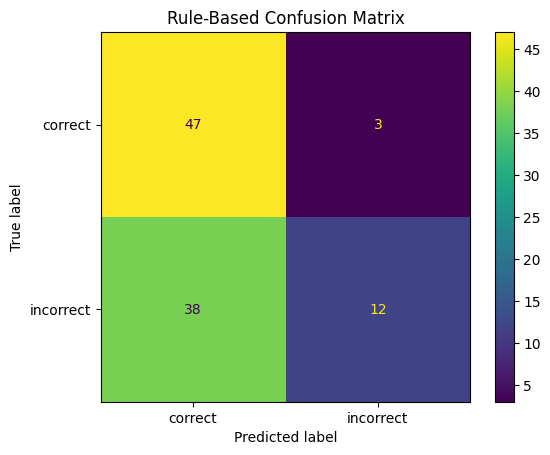

In [8]:
rule_eval_df = rule_video_df[rule_video_df["rule_based_pred"] != "unknown"].copy()

rule_acc = accuracy_score(rule_eval_df["true_label"], rule_eval_df["rule_based_pred"])
print("Rule-based video-level accuracy:", round(rule_acc, 4))

print("\nClassification report:")
print(classification_report(rule_eval_df["true_label"], rule_eval_df["rule_based_pred"]))

cm = confusion_matrix(rule_eval_df["true_label"], rule_eval_df["rule_based_pred"], labels=["correct", "incorrect"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["correct", "incorrect"])
disp.plot()
plt.title("Rule-Based Confusion Matrix")
plt.show()

In [9]:
non_feature_cols = ["video_name", TARGET_COL, "selected_side_<lambda>"]

X = video_df.drop(columns=[col for col in non_feature_cols if col in video_df.columns]).copy()
y = video_df[TARGET_COL].copy()

print("ML feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()

ML feature matrix shape: (100, 39)
Target shape: (100,)


,elbow_angle_2d_smooth_mean,elbow_angle_2d_smooth_std,elbow_angle_2d_smooth_min,elbow_angle_2d_smooth_max,elbow_angle_3d_smooth_mean,elbow_angle_3d_smooth_std,elbow_angle_3d_smooth_min,elbow_angle_3d_smooth_max,body_alignment_angle_2d_smooth_mean,body_alignment_angle_2d_smooth_std,...,knee_angle_3d_smooth_std,knee_angle_3d_smooth_min,knee_angle_3d_smooth_max,elbow_angle_3d_smooth_diff_mean,elbow_angle_3d_smooth_diff_std,body_alignment_angle_3d_smooth_diff_mean,body_alignment_angle_3d_smooth_diff_std,hip_angle_3d_smooth_diff_mean,hip_angle_3d_smooth_diff_std,pose_detected_mean
0,131.529385,50.035481,37.014255,178.079547,132.993026,26.328173,89.582356,166.492159,162.169565,13.178543,...,4.188542,143.099334,161.204132,0.046671,1.939300,-0.024746,0.783435,0.003579,0.775566,1.0
1,143.709620,47.922323,35.975715,180.049503,122.130830,29.776975,58.179325,153.750954,169.437764,5.977260,...,6.751475,145.195764,168.336259,0.126513,3.271578,0.012559,0.735951,0.072174,1.253310,1.0
2,124.318309,61.609328,6.362616,181.277948,117.440292,38.226489,56.695957,156.898092,161.906366,8.052658,...,4.233679,142.208659,157.634884,0.041825,4.245996,0.014363,0.907820,-0.123670,1.163141,1.0
3,140.166148,52.029299,12.468674,180.276857,121.826055,29.163012,63.313515,154.814197,169.852325,6.917945,...,15.576582,103.575214,158.331799,-0.072913,4.102400,0.002196,0.866074,0.004506,1.151618,1.0
4,116.396072,53.141496,13.799650,179.662436,111.174759,27.441589,60.737919,148.277689,162.920529,8.163063,...,10.126725,123.498671,162.702132,-0.019197,3.960415,-0.037395,1.004668,-0.077426,0.950266,1.0


In [10]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))

Classes: ['correct' 'incorrect']
Encoded labels: [0 1]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (80, 39)
Test shape: (20, 39)


In [12]:
mlp_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        batch_size=16,
        learning_rate_init=1e-3,
        max_iter=1000,
        random_state=42
    ))
])

mlp_pipeline.fit(X_train, y_train)
print("MLP training complete.")

MLP training complete.


MLP test accuracy: 0.95

Classification report:
              precision    recall  f1-score   support

     correct       1.00      0.90      0.95        10
   incorrect       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



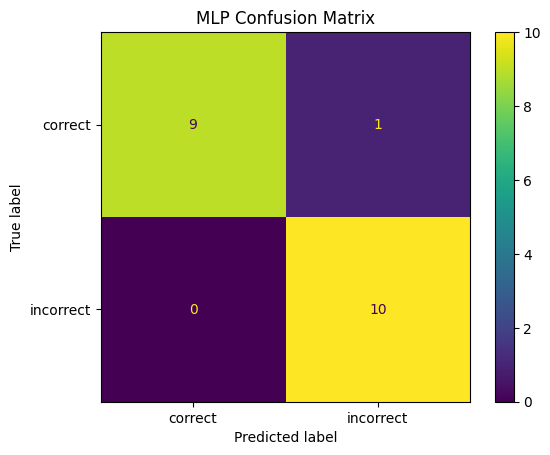

In [13]:
y_pred = mlp_pipeline.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("MLP test accuracy:", round(test_acc, 4))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("MLP Confusion Matrix")
plt.show()

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(mlp_pipeline, X, y_encoded, cv=cv, scoring="accuracy")

print("Cross-validation scores:", np.round(cv_scores, 4))
print("Mean CV accuracy:", round(cv_scores.mean(), 4))
print("Std CV accuracy:", round(cv_scores.std(), 4))

Cross-validation scores: [0.95 0.95 0.9  0.95 0.9 ]
Mean CV accuracy: 0.93
Std CV accuracy: 0.0245


In [15]:
comparison_df = pd.DataFrame({
    "Method": ["Rule-based", "MLP (test split)", "MLP (5-fold CV mean)"],
    "Accuracy": [
        rule_acc,
        test_acc,
        cv_scores.mean()
    ]
})

comparison_df

,Method,Accuracy
0,Rule-based,0.59
1,MLP (test split),0.95
2,MLP (5-fold CV mean),0.93


In [16]:
video_df["mlp_pred"] = label_encoder.inverse_transform(mlp_pipeline.predict(X))
video_df["mlp_pred_proba_incorrect"] = mlp_pipeline.predict_proba(X)[:, list(label_encoder.classes_).index("incorrect")]

video_df[["video_name", TARGET_COL, "mlp_pred", "mlp_pred_proba_incorrect"]].head()

,video_name,label_first,mlp_pred,mlp_pred_proba_incorrect
0,1.mp4,incorrect,incorrect,0.999591
1,10.mp4,incorrect,incorrect,0.999953
2,11.mp4,incorrect,incorrect,0.999704
3,12.mp4,incorrect,incorrect,0.999999
4,13.mp4,incorrect,incorrect,1.000000


In [17]:
def count_repetitions_from_signal(signal, low_threshold=95, high_threshold=145):
    """
    Counts push-up repetitions from an elbow-angle signal.
    
    Logic:
    - a repetition is counted when the signal goes:
      top (high) -> bottom (low) -> top (high)
    """
    state = "top"
    reps = 0
    
    for value in signal:
        if pd.isna(value):
            continue
        
        if state == "top" and value < low_threshold:
            state = "bottom"
        
        elif state == "bottom" and value > high_threshold:
            reps += 1
            state = "top"
    
    return reps

In [18]:
rep_counts = (
    frame_df.sort_values(["video_name", "frame_index"])
    .groupby("video_name")["elbow_angle_3d_smooth"]
    .apply(lambda s: count_repetitions_from_signal(s.values, low_threshold=95, high_threshold=145))
    .reset_index(name="estimated_reps")
)

rep_counts.head()

,video_name,estimated_reps
0,1.mp4,2
1,10.mp4,1
2,11.mp4,1
3,12.mp4,1
4,13.mp4,1


In [19]:
results_df = (
    rule_video_df
    .merge(rep_counts, on="video_name", how="left")
    .merge(
        video_df[["video_name", TARGET_COL, "mlp_pred", "mlp_pred_proba_incorrect"]],
        on="video_name",
        how="left"
    )
)

results_df.head()

,video_name,true_label,rule_based_pred,incorrect_ratio,avg_elbow_angle,min_elbow_angle,avg_body_alignment,min_body_alignment,avg_hip_angle,min_hip_angle,back_not_straight_ratio,hips_too_high_ratio,hips_too_low_ratio,not_low_enough_ratio,estimated_reps,label_first,mlp_pred,mlp_pred_proba_incorrect
0,1.mp4,incorrect,correct,0.310345,132.993026,89.582356,158.766623,136.395964,163.028666,146.605420,0.237931,0.055172,0.0,0.117241,2,incorrect,incorrect,0.999591
1,10.mp4,incorrect,correct,0.349206,122.130830,58.179325,163.943309,156.863558,165.067001,150.340207,0.000000,0.000000,0.0,0.349206,1,incorrect,incorrect,0.999953
2,11.mp4,incorrect,correct,0.192771,117.440292,56.695957,159.207029,147.946818,168.018351,159.533397,0.096386,0.000000,0.0,0.096386,1,incorrect,incorrect,0.999704
3,12.mp4,incorrect,correct,0.404959,121.826055,63.313515,161.849822,151.334442,158.387201,145.231810,0.000000,0.090909,0.0,0.347107,1,incorrect,incorrect,0.999999
4,13.mp4,incorrect,correct,0.231405,111.174759,60.737919,160.207832,143.820613,166.800187,147.615166,0.090909,0.016529,0.0,0.173554,1,incorrect,incorrect,1.000000


In [20]:
def generate_hybrid_feedback(row):
    mlp_pred = row["mlp_pred"]
    
    if mlp_pred == "correct":
        return "Your push-up posture looks correct overall."
    
    messages = []
    
    if row["back_not_straight_ratio"] >= 0.15 or row["min_body_alignment"] < 145:
        messages.append("Keep your body straighter during the movement.")
    
    if row["hips_too_high_ratio"] >= 0.15 or row["min_hip_angle"] < 145:
        messages.append("Do not raise your hips too much.")
    
    if row["hips_too_low_ratio"] >= 0.10:
        messages.append("Do not let your hips drop too low.")
    
    if row["not_low_enough_ratio"] >= 0.15 or row["min_elbow_angle"] > 100:
        messages.append("Go lower at the bottom of the push-up.")
    
    if len(messages) == 0:
        if row["mlp_pred_proba_incorrect"] >= 0.75:
            return "Your push-up posture is incorrect and needs improvement."
        return "Your push-up posture is slightly inconsistent."
    
    return " ".join(messages)

In [21]:
results_df["feedback"] = results_df.apply(generate_hybrid_feedback, axis=1)
results_df.head()

,video_name,true_label,rule_based_pred,incorrect_ratio,avg_elbow_angle,min_elbow_angle,avg_body_alignment,min_body_alignment,avg_hip_angle,min_hip_angle,back_not_straight_ratio,hips_too_high_ratio,hips_too_low_ratio,not_low_enough_ratio,estimated_reps,label_first,mlp_pred,mlp_pred_proba_incorrect,feedback
0,1.mp4,incorrect,correct,0.310345,132.993026,89.582356,158.766623,136.395964,163.028666,146.605420,0.237931,0.055172,0.0,0.117241,2,incorrect,incorrect,0.999591,Keep your body straighter during the movement.
1,10.mp4,incorrect,correct,0.349206,122.130830,58.179325,163.943309,156.863558,165.067001,150.340207,0.000000,0.000000,0.0,0.349206,1,incorrect,incorrect,0.999953,Go lower at the bottom of the push-up.
2,11.mp4,incorrect,correct,0.192771,117.440292,56.695957,159.207029,147.946818,168.018351,159.533397,0.096386,0.000000,0.0,0.096386,1,incorrect,incorrect,0.999704,Your push-up posture is incorrect and needs im...
3,12.mp4,incorrect,correct,0.404959,121.826055,63.313515,161.849822,151.334442,158.387201,145.231810,0.000000,0.090909,0.0,0.347107,1,incorrect,incorrect,0.999999,Go lower at the bottom of the push-up.
4,13.mp4,incorrect,correct,0.231405,111.174759,60.737919,160.207832,143.820613,166.800187,147.615166,0.090909,0.016529,0.0,0.173554,1,incorrect,incorrect,1.000000,Keep your body straighter during the movement....


In [22]:
test_results_df = X_test.copy()
test_results_df["true_label"] = label_encoder.inverse_transform(y_test)
test_results_df["mlp_pred"] = label_encoder.inverse_transform(y_pred)

test_results_df.head(10)

,elbow_angle_2d_smooth_mean,elbow_angle_2d_smooth_std,elbow_angle_2d_smooth_min,elbow_angle_2d_smooth_max,elbow_angle_3d_smooth_mean,elbow_angle_3d_smooth_std,elbow_angle_3d_smooth_min,elbow_angle_3d_smooth_max,body_alignment_angle_2d_smooth_mean,body_alignment_angle_2d_smooth_std,...,knee_angle_3d_smooth_max,elbow_angle_3d_smooth_diff_mean,elbow_angle_3d_smooth_diff_std,body_alignment_angle_3d_smooth_diff_mean,body_alignment_angle_3d_smooth_diff_std,hip_angle_3d_smooth_diff_mean,hip_angle_3d_smooth_diff_std,pose_detected_mean,true_label,mlp_pred
7,141.402075,41.926387,43.462298,174.918054,128.445105,33.009720,43.404513,157.753425,163.850919,9.891242,...,170.123950,0.121981,4.152624,-0.084840,0.771966,-0.008776,0.872728,1.0,incorrect,incorrect
31,135.773102,41.515297,58.414365,179.099231,136.840495,25.640685,93.908211,165.424309,166.284905,10.862379,...,176.976531,-0.006708,1.535300,0.025657,1.036700,-0.002324,0.909104,1.0,incorrect,incorrect
13,143.182057,41.382285,43.518757,175.392554,129.327988,32.263103,44.245024,157.753425,163.621200,9.648020,...,170.123950,0.064982,4.006133,-0.109168,0.697912,-0.017778,0.811617,1.0,incorrect,incorrect
1,143.709620,47.922323,35.975715,180.049503,122.130830,29.776975,58.179325,153.750954,169.437764,5.977260,...,168.336259,0.126513,3.271578,0.012559,0.735951,0.072174,1.253310,1.0,incorrect,incorrect
35,151.095033,38.399056,56.402369,176.542127,140.342257,6.775616,120.190854,151.396377,163.378226,8.818615,...,170.596058,-0.004059,2.102102,0.107884,1.076190,0.059193,1.028182,1.0,correct,incorrect
42,133.862695,33.880772,60.926348,160.765309,134.755097,30.761178,70.602796,160.769935,175.960105,1.250689,...,162.253944,-0.082251,4.022894,0.007588,0.697853,0.159747,0.893309,1.0,correct,correct
48,133.557674,40.476725,58.638651,166.391330,135.791919,35.539845,73.586707,165.120703,175.612345,1.191880,...,164.835025,0.013344,3.306292,-0.067060,0.580242,0.061197,0.708418,1.0,correct,correct
29,133.069749,50.686933,50.499109,204.656128,140.811441,27.090988,91.629768,168.106921,155.645457,9.674843,...,178.703654,-0.052034,3.252436,-0.238836,1.679512,-0.162797,1.295511,1.0,incorrect,incorrect
46,134.267997,36.390397,64.715687,165.853523,135.360392,33.211670,74.952891,165.480795,174.138473,2.589639,...,162.809719,0.088389,3.196064,0.062899,0.803309,0.231385,0.708928,1.0,correct,correct
50,132.827001,45.824887,56.684040,174.072833,135.297116,30.520042,82.629568,164.399118,173.732538,3.175603,...,177.381661,0.039565,2.383988,0.021093,0.695707,0.028341,0.573096,1.0,correct,correct


In [23]:
final_results_df = results_df.rename(columns={TARGET_COL: "true_label_video"})
final_results_df["final_pred"] = final_results_df["mlp_pred"]

final_results_df[[
    "video_name",
    "true_label_video",
    "final_pred",
    "mlp_pred_proba_incorrect",
    "incorrect_ratio",
    "estimated_reps",
    "feedback"
]].head(20)

,video_name,true_label_video,final_pred,mlp_pred_proba_incorrect,incorrect_ratio,estimated_reps,feedback
0,1.mp4,incorrect,incorrect,0.999591,0.310345,2,Keep your body straighter during the movement.
1,10.mp4,incorrect,incorrect,0.999953,0.349206,1,Go lower at the bottom of the push-up.
2,11.mp4,incorrect,incorrect,0.999704,0.192771,1,Your push-up posture is incorrect and needs im...
3,12.mp4,incorrect,incorrect,0.999999,0.404959,1,Go lower at the bottom of the push-up.
4,13.mp4,incorrect,incorrect,1.000000,0.231405,1,Keep your body straighter during the movement....
5,14.mp4,incorrect,incorrect,1.000000,0.328000,1,Keep your body straighter during the movement....
6,15.mp4,incorrect,incorrect,0.999998,0.360000,1,Keep your body straighter during the movement....
7,16.mp4,incorrect,incorrect,1.000000,0.290000,1,Keep your body straighter during the movement....
8,17.mp4,incorrect,incorrect,1.000000,0.691589,1,Keep your body straighter during the movement....
9,18.mp4,incorrect,incorrect,0.999999,0.385621,1,Keep your body straighter during the movement.


In [24]:
example_video = final_results_df["video_name"].iloc[0]

print("Video:", example_video)
print(final_results_df[final_results_df["video_name"] == example_video][[
    "video_name",
    "true_label_video",
    "final_pred",
    "mlp_pred_proba_incorrect",
    "incorrect_ratio",
    "estimated_reps",
    "feedback"
]])

Video: 1.mp4
  video_name true_label_video final_pred  mlp_pred_proba_incorrect  \
0      1.mp4        incorrect  incorrect                  0.999591   

   incorrect_ratio  estimated_reps  \
0         0.310345               2   

                                         feedback  
0  Keep your body straighter during the movement.  


In [25]:
RESULTS_PATH = PROCESSED_DIR / "pushup_posture_results.csv"
RULE_RESULTS_PATH = PROCESSED_DIR / "pushup_rule_based_video_results.csv"

final_results_df.to_csv(RESULTS_PATH, index=False)
rule_video_df.to_csv(RULE_RESULTS_PATH, index=False)

print("Saved final results to:", RESULTS_PATH)
print("Saved rule-based results to:", RULE_RESULTS_PATH)

Saved final results to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\pushup_posture_results.csv
Saved rule-based results to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\pushup_rule_based_video_results.csv


In [26]:
final_results_df[
    (final_results_df["true_label_video"] == "incorrect") &
    (final_results_df["final_pred"] == "incorrect")
][[
    "video_name",
    "true_label_video",
    "final_pred",
    "mlp_pred_proba_incorrect",
    "incorrect_ratio",
    "feedback"
]].head(10)

,video_name,true_label_video,final_pred,mlp_pred_proba_incorrect,incorrect_ratio,feedback
0,1.mp4,incorrect,incorrect,0.999591,0.310345,Keep your body straighter during the movement.
1,10.mp4,incorrect,incorrect,0.999953,0.349206,Go lower at the bottom of the push-up.
2,11.mp4,incorrect,incorrect,0.999704,0.192771,Your push-up posture is incorrect and needs im...
3,12.mp4,incorrect,incorrect,0.999999,0.404959,Go lower at the bottom of the push-up.
4,13.mp4,incorrect,incorrect,1.000000,0.231405,Keep your body straighter during the movement....
5,14.mp4,incorrect,incorrect,1.000000,0.328000,Keep your body straighter during the movement....
6,15.mp4,incorrect,incorrect,0.999998,0.360000,Keep your body straighter during the movement....
7,16.mp4,incorrect,incorrect,1.000000,0.290000,Keep your body straighter during the movement....
8,17.mp4,incorrect,incorrect,1.000000,0.691589,Keep your body straighter during the movement....
9,18.mp4,incorrect,incorrect,0.999999,0.385621,Keep your body straighter during the movement.


In [27]:
final_results_df[
    final_results_df["true_label_video"] != final_results_df["final_pred"]
][[
    "video_name",
    "true_label_video",
    "final_pred",
    "mlp_pred_proba_incorrect",
    "incorrect_ratio",
    "feedback"
]].sort_values("mlp_pred_proba_incorrect", ascending=False)

,video_name,true_label_video,final_pred,mlp_pred_proba_incorrect,incorrect_ratio,feedback
35,Copy of push up 116.mp4,correct,incorrect,0.938479,0.813333,Do not raise your hips too much. Go lower at t...


## Baseline & Comparison

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score

In [29]:
logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logreg_pipeline.fit(X_train, y_train)
print("Logistic Regression training complete.")

Logistic Regression training complete.


In [30]:
y_pred_logreg = logreg_pipeline.predict(X_test)

logreg_test_acc = accuracy_score(y_test, y_pred_logreg)
logreg_bal_acc = balanced_accuracy_score(y_test, y_pred_logreg)
logreg_precision = precision_score(y_test, y_pred_logreg, average="weighted", zero_division=0)
logreg_recall = recall_score(y_test, y_pred_logreg, average="weighted", zero_division=0)
logreg_f1 = f1_score(y_test, y_pred_logreg, average="weighted", zero_division=0)

print("LogReg test accuracy:", round(logreg_test_acc, 4))
print("LogReg balanced accuracy:", round(logreg_bal_acc, 4))
print("LogReg precision:", round(logreg_precision, 4))
print("LogReg recall:", round(logreg_recall, 4))
print("LogReg F1:", round(logreg_f1, 4))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_logreg,
    target_names=label_encoder.classes_
))

LogReg test accuracy: 0.9
LogReg balanced accuracy: 0.9
LogReg precision: 0.9
LogReg recall: 0.9
LogReg F1: 0.9

Classification report:
              precision    recall  f1-score   support

     correct       0.90      0.90      0.90        10
   incorrect       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



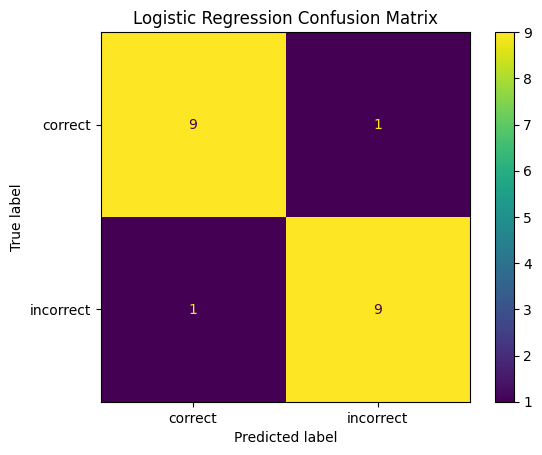

In [31]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=label_encoder.classes_
)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [32]:
cv_scores_logreg = cross_val_score(
    logreg_pipeline,
    X,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

print("LogReg CV scores:", np.round(cv_scores_logreg, 4))
print("LogReg mean CV accuracy:", round(cv_scores_logreg.mean(), 4))
print("LogReg std CV accuracy:", round(cv_scores_logreg.std(), 4))

LogReg CV scores: [1.   0.95 0.9  0.95 0.9 ]
LogReg mean CV accuracy: 0.94
LogReg std CV accuracy: 0.0374


In [33]:
rule_y_true = rule_eval_df["true_label"]
rule_y_pred = rule_eval_df["rule_based_pred"]

rule_bal_acc = balanced_accuracy_score(rule_y_true, rule_y_pred)
rule_precision = precision_score(rule_y_true, rule_y_pred, average="weighted", zero_division=0)
rule_recall = recall_score(rule_y_true, rule_y_pred, average="weighted", zero_division=0)
rule_f1 = f1_score(rule_y_true, rule_y_pred, average="weighted", zero_division=0)

mlp_bal_acc = balanced_accuracy_score(y_test, y_pred)
mlp_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
mlp_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
mlp_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

comparison_baseline_df = pd.DataFrame([
    {
        "Method": "Rule-based",
        "Split": "video-level eval",
        "Accuracy": rule_acc,
        "Balanced Accuracy": rule_bal_acc,
        "Precision": rule_precision,
        "Recall": rule_recall,
        "F1": rule_f1,
        "CV Accuracy Mean": np.nan,
        "CV Accuracy Std": np.nan,
    },
    {
        "Method": "LogReg",
        "Split": "test split",
        "Accuracy": logreg_test_acc,
        "Balanced Accuracy": logreg_bal_acc,
        "Precision": logreg_precision,
        "Recall": logreg_recall,
        "F1": logreg_f1,
        "CV Accuracy Mean": cv_scores_logreg.mean(),
        "CV Accuracy Std": cv_scores_logreg.std(),
    },
    {
        "Method": "MLP",
        "Split": "test split",
        "Accuracy": test_acc,
        "Balanced Accuracy": mlp_bal_acc,
        "Precision": mlp_precision,
        "Recall": mlp_recall,
        "F1": mlp_f1,
        "CV Accuracy Mean": cv_scores.mean(),
        "CV Accuracy Std": cv_scores.std(),
    }
])

comparison_baseline_df.round(4)

,Method,Split,Accuracy,Balanced Accuracy,Precision,Recall,F1,CV Accuracy Mean,CV Accuracy Std
0,Rule-based,video-level eval,0.59,0.59,0.6765,0.59,0.5328,NaN,NaN
1,LogReg,test split,0.90,0.90,0.9000,0.90,0.9000,0.94,0.0374
2,MLP,test split,0.95,0.95,0.9545,0.95,0.9499,0.93,0.0245


In [34]:
video_df["logreg_pred"] = label_encoder.inverse_transform(logreg_pipeline.predict(X))
video_df["logreg_pred_proba_incorrect"] = logreg_pipeline.predict_proba(X)[:, list(label_encoder.classes_).index("incorrect")]

video_df[["video_name", TARGET_COL, "logreg_pred", "logreg_pred_proba_incorrect"]].head()

,video_name,label_first,logreg_pred,logreg_pred_proba_incorrect
0,1.mp4,incorrect,incorrect,0.950278
1,10.mp4,incorrect,incorrect,0.963217
2,11.mp4,incorrect,incorrect,0.979543
3,12.mp4,incorrect,incorrect,0.992507
4,13.mp4,incorrect,incorrect,0.993984


In [35]:
final_comparison_df = final_results_df.merge(
    video_df[["video_name", "logreg_pred", "logreg_pred_proba_incorrect"]],
    on="video_name",
    how="left"
)

final_comparison_df[[
    "video_name",
    "true_label_video",
    "rule_based_pred",
    "logreg_pred",
    "final_pred",
    "mlp_pred_proba_incorrect",
    "logreg_pred_proba_incorrect",
    "feedback"
]].head(20)

,video_name,true_label_video,rule_based_pred,logreg_pred,final_pred,mlp_pred_proba_incorrect,logreg_pred_proba_incorrect,feedback
0,1.mp4,incorrect,correct,incorrect,incorrect,0.999591,0.950278,Keep your body straighter during the movement.
1,10.mp4,incorrect,correct,incorrect,incorrect,0.999953,0.963217,Go lower at the bottom of the push-up.
2,11.mp4,incorrect,correct,incorrect,incorrect,0.999704,0.979543,Your push-up posture is incorrect and needs im...
3,12.mp4,incorrect,correct,incorrect,incorrect,0.999999,0.992507,Go lower at the bottom of the push-up.
4,13.mp4,incorrect,correct,incorrect,incorrect,1.000000,0.993984,Keep your body straighter during the movement....
5,14.mp4,incorrect,correct,incorrect,incorrect,1.000000,0.997318,Keep your body straighter during the movement....
6,15.mp4,incorrect,correct,incorrect,incorrect,0.999998,0.988421,Keep your body straighter during the movement....
7,16.mp4,incorrect,correct,incorrect,incorrect,1.000000,0.999922,Keep your body straighter during the movement....
8,17.mp4,incorrect,incorrect,incorrect,incorrect,1.000000,0.999810,Keep your body straighter during the movement....
9,18.mp4,incorrect,correct,incorrect,incorrect,0.999999,0.999634,Keep your body straighter during the movement.
